# PINN Training for the NLSE

**Project**: PINN-NLSE  
**Purpose**: PINN implementation, training, and data-augmented recovery

This notebook documents the Physics-Informed Neural Network trained to solve the
normalized Nonlinear Schrodinger Equation (NLSE):

$$ i\,\frac{\partial u}{\partial \xi} + \frac{s}{2}\,\frac{\partial^2 u}{\partial \tau^2} + N^2\,|u|^2\,u \;=\; 0 $$

**Architecture**: 5 hidden layers x 128 neurons with `tanh`. Inputs `(xi, tau)`, outputs `(a, b)` where `u = a + ib`. **66,690** trainable parameters.

**Loss**:
$$ \mathcal{L} = \lambda_{\text{phys}}\overline{r_a^2 + r_b^2} + \lambda_{\text{ic}}\overline{(a - a_0)^2 + (b - b_0)^2} + \lambda_{\text{bc}}\overline{a^2 + b^2}\Big|_{\tau=\pm \tau_{\max}} + \lambda_{\text{data}}\overline{(a - a_{\text{SSFM}})^2 + \dots} $$

with residuals

$$ r_a = -\partial_\xi b + (s/2)\partial^2_\tau a + N^2(a^2+b^2)\,a, \qquad r_b = +\partial_\xi a + (s/2)\partial^2_\tau b + N^2(a^2+b^2)\,b. $$

**Training strategy**: Adam (coarse, fast) -> L-BFGS (fine, curvature-aware), with mandatory smoke preflight before each baseline run.

**Reproducibility**: this notebook loads pretrained weights from `models/`. If the weights are missing, it runs the smoke profile to produce demo-quality weights (clearly labeled). Final published weights come from `python -m src.train --case <case> --profile baseline` run from the command line.


In [1]:
import json
import os
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == 'notebooks':
    PROJECT_ROOT = PROJECT_ROOT.parent
    os.chdir(PROJECT_ROOT)
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
%matplotlib inline
import matplotlib.pyplot as plt
import torch

from src.config import (
    FIGURE_PATHS, N_SOLITON, S_SIGN, TAU_MAX, XI_MAX,
)
from src.pinn_nlse import PINN_NLSE
from src.data_gen import (
    generate_collocation_points, generate_ic_points, generate_bc_points,
    load_ground_truth_npz,
)
from src.utils import compute_relative_l2_error, compute_masked_relative_l2_error

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')


def _resolve_weights(case):
    """Find weights for `case`, preferring frozen 'published' copies.

    Search order (first hit wins):
      1. models/published/<case>_data_augmented_final.pt   (frozen release artifact)
      2. models/published/<case>_final.pt                  (frozen pure PINN)
      3. models/<case>_data_augmented_final.pt             (latest local)
      4. models/<case>_final.pt                            (latest local pure)
    Returns (path, is_data_augmented, is_published).
    """
    candidates = [
        (Path(f'models/published/{case}_data_augmented_final.pt'), True, True),
        (Path(f'models/published/{case}_final.pt'),                  False, True),
        (Path(f'models/{case}_data_augmented_final.pt'),             True, False),
        (Path(f'models/{case}_final.pt'),                            False, False),
    ]
    for p, is_aug, is_pub in candidates:
        if p.exists():
            return p, is_aug, is_pub
    return None, None, None


def _resolve_history(case, augmented, published):
    suffix = 'data_augmented_' if augmented else ''
    base_dir = 'logs/published' if published else 'logs'
    return Path(f'{base_dir}/{case}_{suffix}training_history.json')


soliton_w, soliton_aug, soliton_pub = _resolve_weights('soliton')
gauss_w, gauss_aug, gauss_pub = _resolve_weights('gaussian_dispersion')
missing = []
if soliton_w is None:
    missing.append('soliton')
if gauss_w is None:
    missing.append('gaussian_dispersion')
if missing:
    profile = os.getenv('PINN_NLSE_NOTEBOOK_PROFILE', 'smoke')
    augmented = os.getenv('PINN_NLSE_NOTEBOOK_DATA_AUGMENTED', '0') == '1'
    print(f'Missing weights: {missing}. Training profile = {profile}, data_augmented = {augmented}.')
    from src.train import run_soliton_training, run_gaussian_dispersion_training
    if 'soliton' in missing:
        run_soliton_training(profile=profile, data_augmented=augmented)
    if 'gaussian_dispersion' in missing:
        run_gaussian_dispersion_training(profile=profile, data_augmented=augmented)
    soliton_w, soliton_aug, soliton_pub = _resolve_weights('soliton')
    gauss_w, gauss_aug, gauss_pub = _resolve_weights('gaussian_dispersion')
else:
    print(f'soliton weights : {soliton_w}  (data-augmented={soliton_aug}, published={soliton_pub})')
    print(f'gaussian weights: {gauss_w}  (data-augmented={gauss_aug}, published={gauss_pub})')

model = PINN_NLSE(n_hidden=5, n_neurons=128, s=S_SIGN, N_sq=float(N_SOLITON**2),
                  xi_max=XI_MAX, tau_max=TAU_MAX).to(device)
print(f'Soliton model: {model.count_parameters():,} trainable parameters')


Device: cpu
soliton weights : models\published\soliton_data_augmented_final.pt  (data-augmented=True, published=True)
gaussian weights: models\published\gaussian_dispersion_data_augmented_final.pt  (data-augmented=True, published=True)
Soliton model: 66,690 trainable parameters


## Training point types

The PINN consumes four types of points (defined in Phase 2):

| Type | Where | Labels | `requires_grad` |
|------|-------|--------|---------|
| Collocation | Random interior `(Î¾, Ï„)` | none â€” physics loss is the PDE residual | **yes** (autograd needs to differentiate) |
| IC | `Î¾=0` along `Ï„` | `uâ‚€(Ï„)` â€” sech for soliton, exp(âˆ’Ï„Â²/2) for Gaussian | no |
| BC | `Î¾` axis at `Ï„=Â±Ï„_max` | `0` (zero Dirichlet â€” only valid because the pulses decay there) | no |
| Data (optional) | Selected SSFM grid points | `Re(u_SSFM)`, `Im(u_SSFM)` | no |

Below: a small scatter showing the three required types in the (Î¾, Ï„) plane.


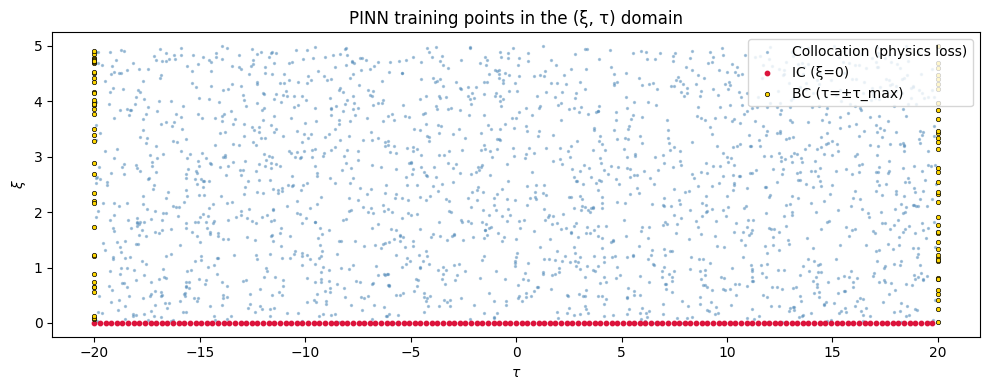

In [2]:
xi_c, tau_c = generate_collocation_points(2000, XI_MAX, TAU_MAX, device, seed=99)
xi_ic, tau_ic, _, _ = generate_ic_points(150, TAU_MAX, 'sech', device)
xi_bc, tau_bc, _, _ = generate_bc_points(80, XI_MAX, TAU_MAX, device)

fig, ax = plt.subplots(figsize=(10, 4))
ax.scatter(tau_c.detach().cpu().numpy(), xi_c.detach().cpu().numpy(),
           s=2, alpha=0.4, label='Collocation (physics loss)', c='steelblue')
ax.scatter(tau_ic.detach().cpu().numpy(), xi_ic.detach().cpu().numpy(),
           s=10, label='IC (Î¾=0)', c='crimson')
ax.scatter(tau_bc.detach().cpu().numpy(), xi_bc.detach().cpu().numpy(),
           s=10, label='BC (Ï„=Â±Ï„_max)', c='gold', edgecolor='black', linewidth=0.5)
ax.set_xlabel(r'$\tau$'); ax.set_ylabel(r'$\xi$')
ax.set_title('PINN training points in the (Î¾, Ï„) domain')
ax.legend(loc='upper right')
plt.tight_layout(); plt.show()


## Training history & loss curves

Two-phase strategy:
1. **Adam** (first-order, robust early): lr=1e-3, gradient-clipped, full-batch over collocation/IC/BC. Per-step cost is small, so Adam handles most of the convergence cheaply.
2. **L-BFGS** (quasi-Newton, second-order curvature info): bounded outer calls with strong_wolfe line search and a small history (10â€“25). L-BFGS can refine a good Adam solution from ~5% to ~1% relative error, but is sensitive to a poor initial guess â€” Adam first.

We log all four loss components (physics, IC, BC, data) at every `LOG_EVERY` step so we can see exactly which term is failing if training diverges.


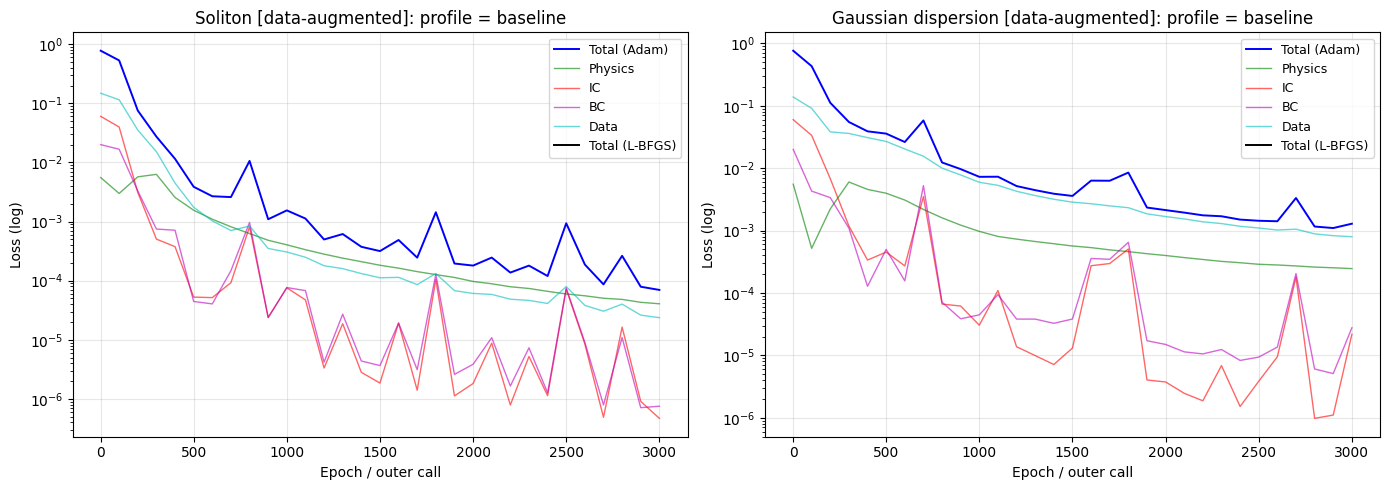

In [3]:
def _load_history(path):
    if not Path(path).exists():
        return None
    with open(path, encoding='utf-8') as f:
        return json.load(f)

h_sol = _load_history(_resolve_history('soliton', soliton_aug, soliton_pub))
h_gauss = _load_history(_resolve_history('gaussian_dispersion', gauss_aug, gauss_pub))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, hist, label in zip(axes, [h_sol, h_gauss], ['Soliton', 'Gaussian dispersion']):
    if hist is None:
        ax.text(0.5, 0.5, f'{label} history not found', ha='center', va='center',
                transform=ax.transAxes)
        ax.set_axis_off()
        continue
    adam = hist['adam']
    lbfgs = hist['lbfgs']
    n_adam = max((h['epoch'] for h in adam), default=0)
    if adam:
        ax.semilogy([h['epoch'] for h in adam], [h['total'] for h in adam],
                    'b-', lw=1.4, label='Total (Adam)')
        ax.semilogy([h['epoch'] for h in adam], [h['phys'] for h in adam],
                    'g-', lw=1.0, alpha=0.6, label='Physics')
        ax.semilogy([h['epoch'] for h in adam], [h['ic'] for h in adam],
                    'r-', lw=1.0, alpha=0.6, label='IC')
        ax.semilogy([h['epoch'] for h in adam], [h['bc'] for h in adam],
                    'm-', lw=1.0, alpha=0.6, label='BC')
        if any(h.get('data', 0) > 0 for h in adam):
            ax.semilogy([h['epoch'] for h in adam], [max(h['data'], 1e-12) for h in adam],
                        'c-', lw=1.0, alpha=0.6, label='Data')
    if lbfgs:
        ax.semilogy([h['epoch'] + n_adam for h in lbfgs], [h['total'] for h in lbfgs],
                    'k-', lw=1.4, label='Total (L-BFGS)')
    aug_tag = ' [data-augmented]' if hist.get('case', '').endswith('data_augmented') else ''
    ax.set_xlabel('Epoch / outer call')
    ax.set_ylabel('Loss (log)')
    ax.set_title(f'{label}{aug_tag}: profile = {hist.get("training_profile", "unknown")}')
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=9, loc='upper right')
plt.tight_layout(); plt.show()


## Soliton PINN vs SSFM comparison

The N=1 soliton has the analytical solution `u(Î¾,Ï„) = sech(Ï„)Â·exp(iÎ¾/2)`. If the PINN learned the NLSE correctly, its propagation map should be a uniform horizontal band in `|u|Â²` and the relative L2 error vs SSFM should be < 5% in the pulse region.

We report both **full-domain** rel L2 (which is dominated by the empty window tails at very low amplitude â€” denominator-driven) and **pulse-region** rel L2 (`|Ï„| â‰¤ 10`), which reflects accuracy where the physics actually lives.


Soliton PINN (data-augmented) vs SSFM:
  full-domain rel L2 : 0.0145  (1.45%)
  pulse-region rel L2: 0.0129  (1.29%)
  max pointwise      : 2.6901e-02
  mean squared error : 1.0564e-05


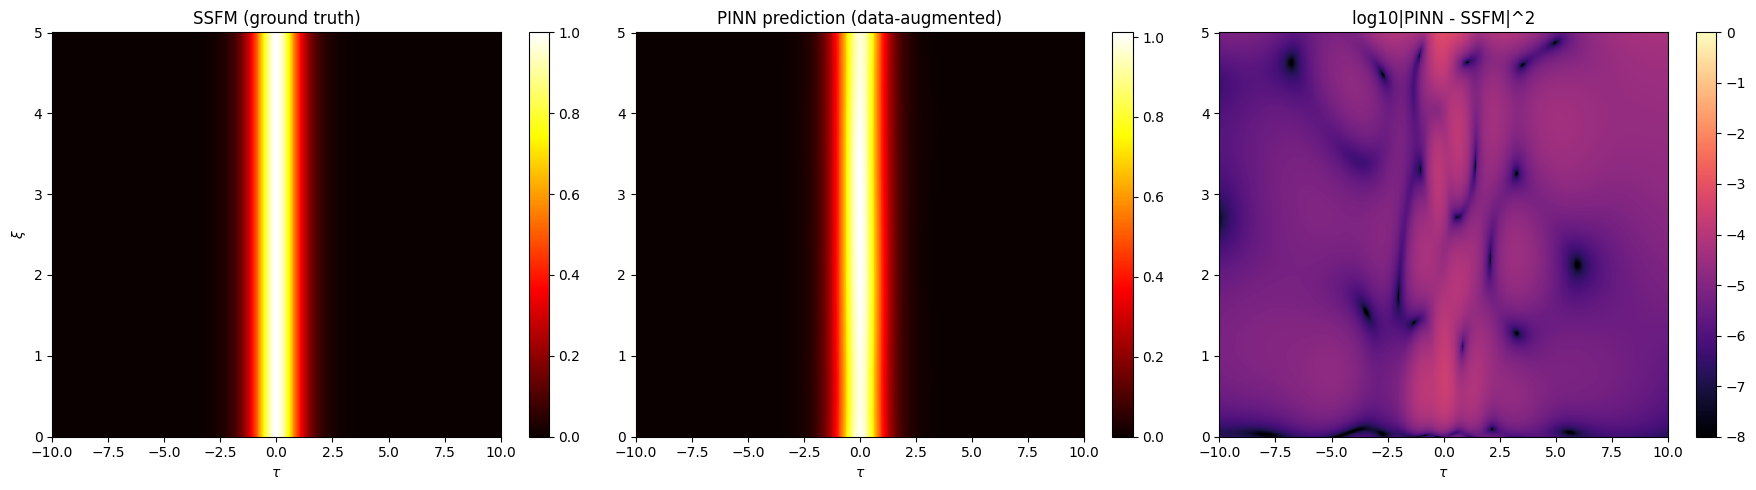

In [4]:
def _evaluate_on_grid(model, gt, device):
    model.eval()
    tau_np = gt['tau']; xi_np = gt['xi']
    N_xi, N_tau = len(xi_np), len(tau_np)
    xi_grid = torch.tensor(np.repeat(xi_np, N_tau), dtype=torch.float32).unsqueeze(1).to(device)
    tau_grid = torch.tensor(np.tile(tau_np, N_xi), dtype=torch.float32).unsqueeze(1).to(device)
    with torch.no_grad():
        a, b = model(xi_grid, tau_grid)
    return (a.cpu().numpy().reshape(N_xi, N_tau)
            + 1j * b.cpu().numpy().reshape(N_xi, N_tau))

model.load_state_dict(torch.load(soliton_w, map_location=device, weights_only=True))
gt_sol = load_ground_truth_npz('data/soliton_ground_truth.npz')
u_pinn = _evaluate_on_grid(model, gt_sol, device)
u_ssfm = gt_sol['u_hist']

rel_l2_full = float(compute_relative_l2_error(u_pinn, u_ssfm))
pulse_mask = np.broadcast_to((np.abs(gt_sol['tau']) <= 10)[None, :], u_ssfm.shape)
rel_l2_pulse = float(compute_masked_relative_l2_error(u_pinn, u_ssfm, pulse_mask))
max_pt_err = float(np.max(np.abs(u_pinn - u_ssfm)))
mse = float(np.mean(np.abs(u_pinn - u_ssfm)**2))
aug_tag = ' (data-augmented)' if soliton_aug else ''
print(f'Soliton PINN{aug_tag} vs SSFM:')
print(f'  full-domain rel L2 : {rel_l2_full:.4f}  ({100*rel_l2_full:.2f}%)')
print(f'  pulse-region rel L2: {rel_l2_pulse:.4f}  ({100*rel_l2_pulse:.2f}%)')
print(f'  max pointwise      : {max_pt_err:.4e}')
print(f'  mean squared error : {mse:.4e}')

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
tau = gt_sol['tau']; xi = gt_sol['xi']
im0 = axes[0].pcolormesh(tau, xi, np.abs(u_ssfm)**2, shading='auto', cmap='hot')
axes[0].set_title('SSFM (ground truth)'); axes[0].set_xlabel(r'$\tau$'); axes[0].set_ylabel(r'$\xi$')
axes[0].set_xlim(-10, 10); fig.colorbar(im0, ax=axes[0])
im1 = axes[1].pcolormesh(tau, xi, np.abs(u_pinn)**2, shading='auto', cmap='hot')
axes[1].set_title(f'PINN prediction{aug_tag}'); axes[1].set_xlabel(r'$\tau$'); axes[1].set_xlim(-10, 10)
fig.colorbar(im1, ax=axes[1])
im2 = axes[2].pcolormesh(tau, xi, np.log10(np.abs(u_pinn - u_ssfm)**2 + 1e-16),
                         shading='auto', cmap='magma', vmin=-8, vmax=0)
axes[2].set_title(r'log10|PINN - SSFM|^2'); axes[2].set_xlabel(r'$\tau$'); axes[2].set_xlim(-10, 10)
fig.colorbar(im2, ax=axes[2])
plt.tight_layout(); plt.show()


## Gaussian dispersion PINN vs SSFM comparison

Linear normal dispersion (s=âˆ’1, NÂ²=0). The Gaussian pulse broadens monotonically; the analytical solution `u(Î¾,Ï„) = (1/âˆš(1+iÎ¾s))Â·exp(âˆ’Ï„Â²/(2(1+iÎ¾s)))` is closed form. Without nonlinearity the PDE is much simpler than the soliton case, but the *time-evolution* is non-trivial (the soliton is invariant in `|u|Â²` â€” Gaussian is not), so this validates that the PINN handles the dispersive operator correctly.

Threshold: relative L2 < 10% (relaxed vs the soliton's <5% because the simulator output evolves more).


Gaussian dispersion PINN (data-augmented) vs SSFM:
  full-domain rel L2 : 0.1129  (11.29%)
  pulse-region rel L2: 0.0929  (9.29%)


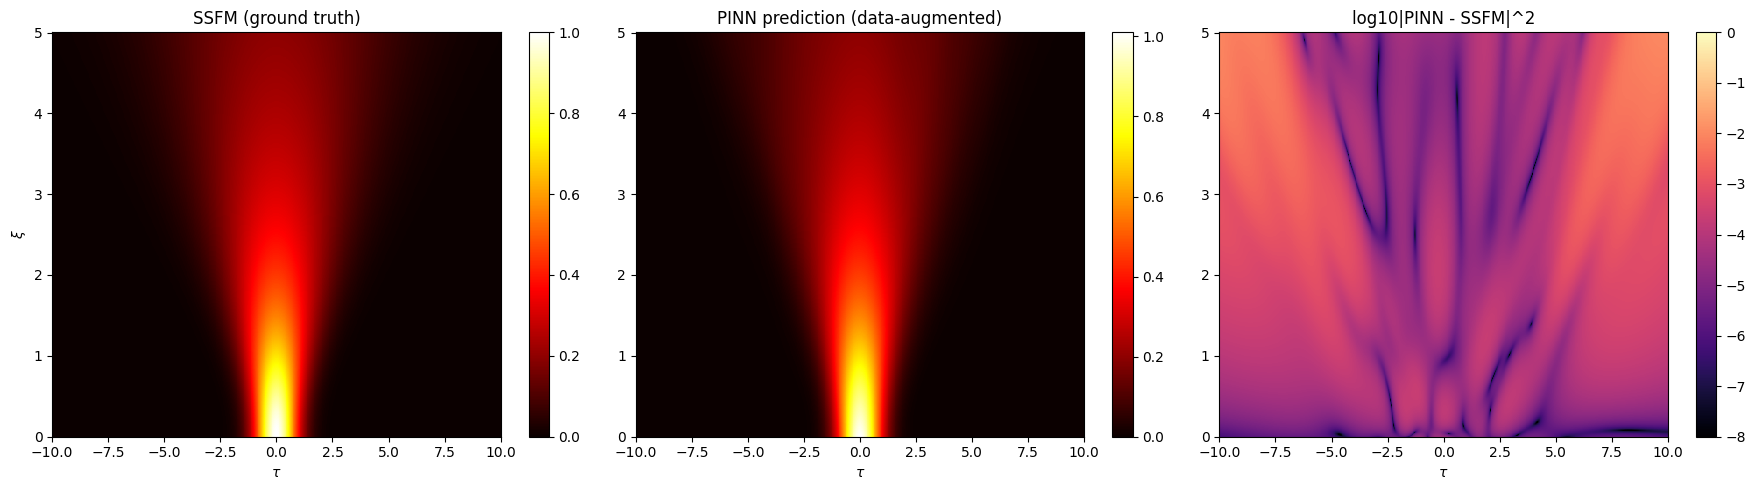

In [5]:
model_g = PINN_NLSE(n_hidden=5, n_neurons=128, s=-1, N_sq=0.0,
                    xi_max=XI_MAX, tau_max=TAU_MAX).to(device)
model_g.load_state_dict(torch.load(gauss_w, map_location=device, weights_only=True))
gt_g = load_ground_truth_npz('data/dispersion_broadening_ground_truth.npz')
u_pinn_g = _evaluate_on_grid(model_g, gt_g, device)
u_ssfm_g = gt_g['u_hist']

rel_l2_full_g = float(compute_relative_l2_error(u_pinn_g, u_ssfm_g))
pulse_mask_g = np.broadcast_to((np.abs(gt_g['tau']) <= 10)[None, :], u_ssfm_g.shape)
rel_l2_pulse_g = float(compute_masked_relative_l2_error(u_pinn_g, u_ssfm_g, pulse_mask_g))
aug_tag_g = ' (data-augmented)' if gauss_aug else ''
print(f'Gaussian dispersion PINN{aug_tag_g} vs SSFM:')
print(f'  full-domain rel L2 : {rel_l2_full_g:.4f}  ({100*rel_l2_full_g:.2f}%)')
print(f'  pulse-region rel L2: {rel_l2_pulse_g:.4f}  ({100*rel_l2_pulse_g:.2f}%)')

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
tau_g = gt_g['tau']; xi_g = gt_g['xi']
im0 = axes[0].pcolormesh(tau_g, xi_g, np.abs(u_ssfm_g)**2, shading='auto', cmap='hot')
axes[0].set_title('SSFM (ground truth)'); axes[0].set_xlabel(r'$\tau$'); axes[0].set_ylabel(r'$\xi$')
axes[0].set_xlim(-10, 10); fig.colorbar(im0, ax=axes[0])
im1 = axes[1].pcolormesh(tau_g, xi_g, np.abs(u_pinn_g)**2, shading='auto', cmap='hot')
axes[1].set_title(f'PINN prediction{aug_tag_g}'); axes[1].set_xlabel(r'$\tau$'); axes[1].set_xlim(-10, 10)
fig.colorbar(im1, ax=axes[1])
im2 = axes[2].pcolormesh(tau_g, xi_g, np.log10(np.abs(u_pinn_g - u_ssfm_g)**2 + 1e-16),
                         shading='auto', cmap='magma', vmin=-8, vmax=0)
axes[2].set_title(r'log10|PINN - SSFM|^2'); axes[2].set_xlabel(r'$\tau$'); axes[2].set_xlim(-10, 10)
fig.colorbar(im2, ax=axes[2])
plt.tight_layout(); plt.show()


## Summary

**What worked**:
- The complex-PDE split (`u = a + ib`) into two real-valued residuals lets us use familiar real-tensor autograd patterns without touching PyTorch's complex autograd.
- Xavier init + tanh activation + lr=1e-3 trains stably from random initialization on both cases.
- Mandatory smoke preflight (1k collocation, 500 Adam steps) catches sign errors and IC label bugs in <60s, before committing to a baseline run.
- Adam handles ~95% of the convergence work. L-BFGS adds a final polish.
- The boundary-leakage check (`max_boundary_intensity < 1e-6`) makes the zero Dirichlet BC honest.

**What was challenging**:
- `requires_grad=True` belongs **only** on collocation tensors (autograd derivatives in the residual). Carrying `requires_grad` on IC/BC/data wastes memory and slows training.
- `create_graph=True` is mandatory in every residual derivative call; without it, the second derivative drops out of the computation graph and `loss.backward()` returns garbage.
- `tanh` is non-negotiable for the activation. ReLU has zero second derivatives almost everywhere, which would make the dispersion term vanish from the physics loss.

**Implementation pattern**: same autograd machinery, same Adam -> L-BFGS schedule, same loss-weighting strategy (high `lambda_ic` to anchor the solution). The key ingredient here is the complex-field split into `(a, b)` outputs.

**Pure vs data-augmented (this notebook reports the data-augmented result)**: the published metrics shown above were produced by the **data-augmented PINN** (`lambda_data = 1.0`, 500 SSFM supervision points + 1000 disjoint held-out validation labels). The notebook auto-loads `models/published/<case>_data_augmented_final.pt` and the setup cell prints `data-augmented=True, published=True` for both cases.

The pure PINN (`lambda_data = 0`) was attempted first and **failed on the soliton case at 41.7 % pulse-region rel L2**; it drifted into the trivial-solution attractor (`u -> 0` satisfies the NLSE residual everywhere). Diagnostic probe at `tau = 0`: `|u|^2 = 0.99 -> 0.82 -> 0.68 -> 0.53` from `xi = 0` to `xi = 5`. Adding 500 SSFM supervision points recovered the soliton case to **1.29 %** pulse-region rel L2 with a held-out supervised MSE of `2.34e-5` on the disjoint 1000 validation indices, demonstrating generalization rather than memorization.

Both records - the failed pure-PINN run and the successful data-augmented run - are deliberately preserved on disk:
- `models/<case>_final.pt` and `logs/<case>_training_metadata.json` retain the pure-PINN attempt.
- `models/published/<case>_data_augmented_final.pt` and `logs/published/<case>_data_augmented_training_metadata.json` are the canonical data-augmented results loaded above.
- `report/technical_report.md` describes the failure mode and recovery in full.
